In [63]:
# importing different modules
# numpy is for math and matrix/vector stuff
# matplotlib is for visualizing data
# PIL allows for opening image files
# torchvision and torch are for ML handling
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.transforms import v2
import torchvision.models as models
import torch

# os and sys allow us to do stuff with files
import os
import sys

In [2]:
## taken from pytorch forums
# creates an array of class labels where idx2label[i] is the string label associated with class i
import json
class_idx = json.load(open("imagenet_class_index.json"))
idx2label = np.array([class_idx[str(k)][1] for k in range(len(class_idx))])
#print(idx2label)
def convertIndexToLabel(i):
    return idx2label[i]

# using the imagenet official correct validation classifications, turns those class numbers into a list of classification names
# these are the "correct" classes for each image in the dataset
file_path = 'val.txt'
true_class_nums = np.loadtxt(file_path, dtype = int)
true_class_names = convertIndexToLabel(true_class_nums)

In [3]:

# Defining the different models, using pretrained weights
alexnet = models.alexnet(weights=models.AlexNet_Weights.DEFAULT)
resnet = models.resnet34(weights = models.ResNet34_Weights.DEFAULT)
convnext = models.convnext_base(weights = models.ConvNeXt_Base_Weights.DEFAULT)


# Setting the models to evaluation mode
alexnet.eval()
resnet.eval()
convnext.eval()

# Get the preprocessing transformations necessary in order for the models to take the image inputs
alex_preprocess = models.AlexNet_Weights.DEFAULT.transforms()
res_preprocess = models.ResNet34_Weights.DEFAULT.transforms()
conv_preprocess = models.ConvNeXt_Base_Weights.DEFAULT.transforms()


# setup that allows us to iterate through the different models
class modelinfo:
    def __init__(self, model, preprocess):
        self.name = model._get_name()
        self.model = model
        self.preprocess = preprocess
alexinfo = modelinfo(alexnet, alex_preprocess)
resinfo = modelinfo(resnet, res_preprocess)
convinfo = modelinfo(convnext, conv_preprocess)
used_models = [alexinfo, resinfo, convinfo]

In [64]:
def inference_single_image (input, model):
    
    # gets the "probability" for each class
    prob = torch.nn.functional.softmax(model.model(input)[0], dim=0)
    # sorts the class labels in order from highest to lowest "probability"
    sorted_prob_label = sorted(zip(prob, idx2label), reverse = True)
    sorted_prob, sorted_label = zip(*list(sorted_prob_label))
    # gets the predicted label
    label = sorted_label[0]
    # adds a copy of the image so we can display alongside data below
    return label

def load_image (filename, model):
    img = Image.open("imagenet_val_dataset/"+filename)
    #img_np = np.array(img)
    #img.convert("RGB") is important because some images are in black-and-white,
    #which means they have a different tensor size as colored images, since they 
    #are missing a color channel
    input = model.preprocess(img.convert("RGB")).unsqueeze(0)
    img_np = input.numpy()
    return input, img_np

# adds gaussian noise to the input image. Noiseparams is (mean, standard deviation) for the gaussian noise.
def load_image_noise(filename, model, noiseparams):
    mean, stdev = noiseparams
    pre_noise, _ = load_image(filename, model)
    noise_func = v2.GaussianNoise(mean, stdev)
    input = noise_func(pre_noise)

    img_np = input.numpy()
    return input, img_np

In [ ]:

# Runs all the images from start to num_iter through the model
# it will then add the labels, and images (as numpy array) to associated arrays for further analysis
def inference(misclassified_file, model, preprocess, num_iter = float('inf')):
    model_np_imgs = []
    flag = True

    with open(misclassified_file, 'r') as listfile:
        misclassified_list = [line.rstrip() for line in listfile]
    
    print(model.name)
    labels = []
    count = 0
    for file in misclassified_list:
        if count == num_iter:
            break
        #print(file[-5:])
        # running the files through the model
        if file[-5:] == ".JPEG":
            # code for making countdown
            print(f"\r{count+1}/{min(num_iter, len(misclassified_list))}", end="")
            sys.stdout.flush()
            count += 1
            input, img_np = preprocess(file, model)
            label = inference_single_image(input, model)
            if img_np is not None:
                model_np_imgs.append(img_np)
            labels.append(label)

    
    print("")
    return labels, model_np_imgs

In [ ]:
alex_labels, alex_imgs = inference("misclassified_images_by_class/AlexNet", alexinfo, load_image, 10)


AlexNet
10/10


In [59]:
def display_images(images):
    size = int(np.ceil(np.sqrt(len(images))))
    fig, axes = plt.subplots(size, size, figsize = (10,10) )
    for i, img in enumerate(images):
        #print("blah")
        #img_np = img.transpose(1,2,0)
        row = i//size
        col = i%size
        axes[row][col].imshow(img[0].transpose(1,2,0))
        axes[row][col].axis('off')
    plt.tight_layout
    plt.show

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6384109..1.9776908].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8044444..2.622571].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4134207].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.980906..1.907974].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9295317..2.1171243].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4

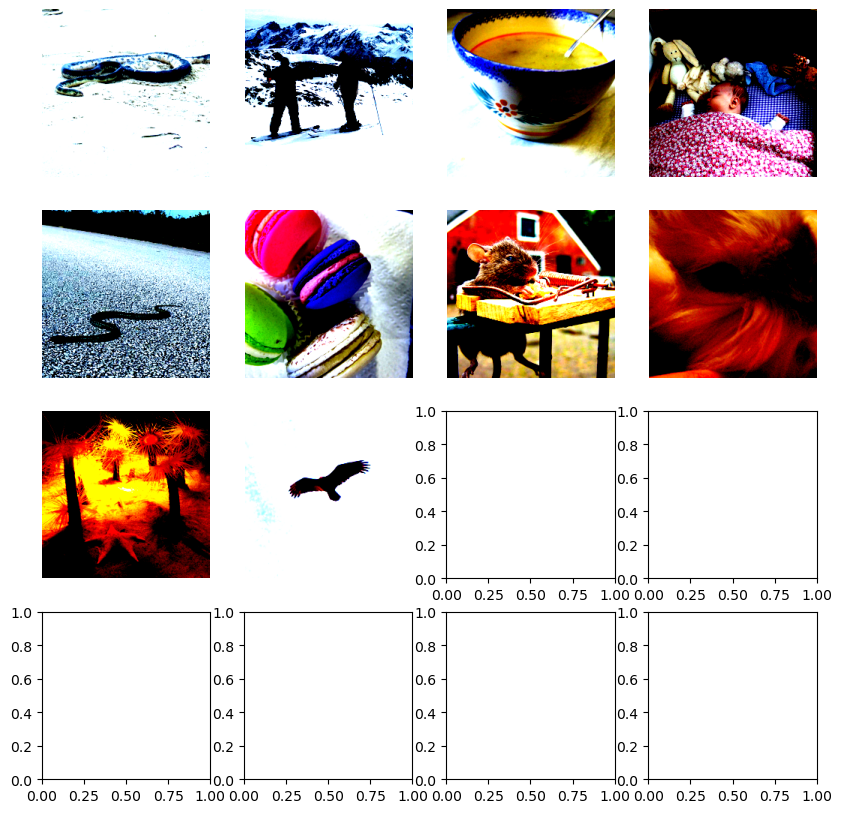

In [61]:
display_images(alex_imgs)

AlexNet
10/10
[np.str_('leatherback_turtle'), np.str_('ski'), np.str_('cup'), np.str_('beagle'), np.str_('diamondback'), np.str_('bath_towel'), np.str_('fox_squirrel'), np.str_('Maltese_dog'), np.str_('quill'), np.str_('kite')]
[np.str_('nematode'), np.str_('German_short-haired_pointer'), np.str_('soup_bowl'), np.str_('bassinet'), np.str_('doormat'), np.str_('bath_towel'), np.str_('book_jacket'), np.str_('volcano'), np.str_('book_jacket'), np.str_('kite')]


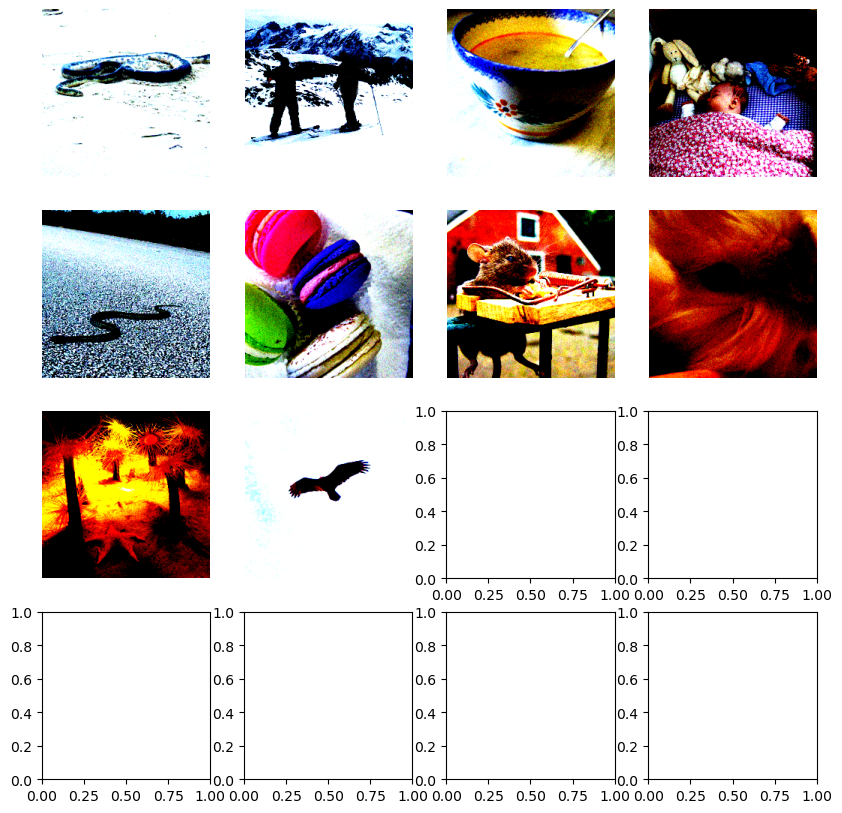

In [72]:
from functools import partial
testNoise = partial(load_image_noise, noiseparams=(0, 0.1))
noise_alex_labels, noise_alex_imgs = inference("misclassified_images_by_class/AlexNet", alexinfo, testNoise, 10)
display_images(noise_alex_imgs)
print(alex_labels)
print(noise_alex_labels)

In [ ]:
alex_labels = inference("misclassified_images_by_class/AlexNet", alexinfo, load_image)
res_labels = inference("misclassified_images_by_class/ResNet", resinfo, load_image)
next_labels = inference("misclassified_images_by_class/ConvNeXt", convinfo, load_image)

AlexNet
2964/21689

KeyboardInterrupt: 